# Projekt UNS 2025 – LSTM predikcia typu písmena
Úloha: pre slovo, kde je práve jedno písmeno nahradené znakom x, predikovať typ pôvodného písmena:
- krátka samohláska
- dlhá samohláska
- spoluhláska

Oleksandr Kletsko


# Importy


In [294]:
import numpy as np
import re
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Settings


In [295]:
KRATKE = "aäeiyouô"   # kratke samohlasky (podla zadania)
DLHE = "áéíýóú"      # dlhe samohlasky (podla zadania)

MAX_LEN = 20  #max dlzka slova
DATA_LEN = 40000 #max dlzka dat

ALFABET = " abcdefghijklmnopqrstuvwxyzáäčďéíĺľňóôŕšťúýžx"
char2idx = {c: i for i, c in enumerate(ALFABET)}
vocab_size = len(ALFABET)



# Nacitanie slov z data.txt

In [309]:

with open("data.txt", "r", encoding="utf-8") as f:
    txt = f.read().lower()

words = re.findall(r"[a-záäčďéíĺľňóôŕšťúýž]+", txt)

np.random.shuffle(words)
words = words[:DATA_LEN]
len(words)


40000

# Preprocessing, nahradenie jedneho znaku za 'x' v slovach , rozdiel do tried



In [310]:
X_data = []
y_data = []

counts = [0, 0, 0]
target = DATA_LEN // 3

for w in words:
    if len(X_data) >= DATA_LEN:
        break

    if "x" in w:
        continue

    if not (3 <= len(w) <= MAX_LEN):
        continue

    p0 = [i for i, ch in enumerate(w) if ch in KRATKE]
    p1 = [i for i, ch in enumerate(w) if ch in DLHE]
    p2 = [i for i, ch in enumerate(w) if (ch not in KRATKE) and (ch not in DLHE)]

    avail = []
    if p0: avail.append(0)
    if p1: avail.append(1)
    if p2: avail.append(2)

    best = avail[0]

    for c in avail:
        if counts[c] < counts[best]:
            if counts[c] < target or counts[best] >= target:
                best = c

    label = best
    if label == 0:
        idx = np.random.choice(p0)
    elif label == 1:
        idx = np.random.choice(p1)
    else:
        idx = np.random.choice(p2)

    masked = list(w)
    masked[idx] ="x"

    nums = [char2idx.get(c, 0) for c in masked]
    nums = nums +[0]*(MAX_LEN - len(nums))

    X_data.append(nums)
    y_data.append(label)
    counts[label] +=1

X_data = np.array(X_data)
y_data = np.array(y_data)

print("Vzorky:", len(X_data))
print("Class counts:", np.bincount(y_data))


Vzorky: 36675
Class counts: [12226 12224 12225]


In [311]:
X = to_categorical(X_data, num_classes=vocab_size)
y = y_data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)

print(X_train.shape)
print(y_train.shape)


(29340, 20, 45)
(29340,)


# Modeling


In [312]:
def build_model(): #pouzijeme aj v analyze
    model = Sequential()
    model.add(layers.InputLayer(shape=(MAX_LEN, vocab_size)))
    model.add(layers.LSTM(32))
    model.add(layers.Dense(16, "relu"))
    model.add(layers.Dense(3, "softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [313]:
model = build_model()
model.summary()

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)


Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_81 (LSTM)                  │ (None, 32)             │         9,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_162 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_163 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,563 (41.26 KB)

 Trainable params: 10,563 (41.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.4725 - loss: 0.9409 - val_accuracy: 0.7297 - val_loss: 0.5966
Epoch 2/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7755 - loss: 0.5077 - val_accuracy: 0.8645 - val_loss: 0.3714
Epoch 3/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8808 - loss: 0.3238 - val_accuracy: 0.8954 - val_loss: 0.2930
Epoch 4/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9264 - loss: 0.2268 - val_accuracy: 0.9048 - val_loss: 0.2650
Epoch 5/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.9449 - loss: 0.1772 - val_accuracy: 0.9576 - val_loss: 0.1497
Epoch 6/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9578 - loss: 0.1446 - val_accuracy: 0.9606 - val_loss: 0.1428
Epoch 7/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9631 - loss: 0.1257 - val_accuracy: 0.9482 - val_loss: 0.1813
Epoch 8/10
459/459 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9699 - loss: 0.1053 - val_acc

# Evoluation

Presnost na testovacich datach: 96.82%


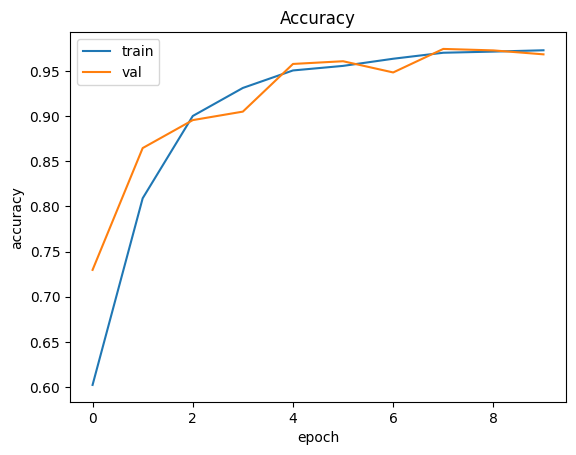

In [314]:
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Presnost na testovacich datach: {acc*100:.2f}%")
plt.figure()
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend(["train","val"])
plt.show()

# Demo

In [317]:
triedy= {0: "krátka samohláska", 1: "dlhá samohláska", 2: "spoluhláska"}

print("Zadajte slovo (s 'x', napr: Kolxče , kaxustnica , vxľký ):")
word = input().strip().lower()

nums = [char2idx.get(c, 0) for c in word]
if len(nums) < MAX_LEN:
    nums = nums + [0] * (MAX_LEN - len(nums))
else:
    nums = nums[:MAX_LEN]

x_in = to_categorical(np.array([nums]), num_classes=vocab_size)
res = model.predict(x_in, verbose=0)[0]
pred = int(np.argmax(res))

print(f"Predikcia: {triedy[pred]}")

print("Zadajte pôvodné písmeno na mieste x (pre kontrolu):")
true_ch = input().strip().lower()

if true_ch in KRATKE:
    true_label = 0
elif true_ch in DLHE:
    true_label = 1
else:
    true_label = 2

print(f"Spravna odpoved: {triedy[true_label]}")


Zadajte slovo (s 'x', napr: Kolxče , kaxustnica , vxľký ):
vxľký 
Predikcia: krátka samohláska
Zadajte pôvodné písmeno na mieste x (pre kontrolu):


KeyboardInterrupt: Interrupted by user

# Analyza vplyvu velkosti datasetu

In [318]:
n = len(X_train)

sizes = [1000, 2000, 5000, 10000, n]
sizes = sorted({s for s in sizes if s <= n})

accuracies = []

for s in sizes:
    model_analyz = build_model()
    model_analyz.fit(
        X_train[:s], y_train[:s],
        epochs=5,
        batch_size=128,
        verbose=0
    )
    loss, acc = model_analyz.evaluate(X_test, y_test, verbose=0)
    accuracies.append(acc)

for s, a in zip(sizes, accuracies):
    print( f"Velkost -->{s} , Presnost --> {a*100:.2f}%")

Velkost -->1000 , Presnost --> 33.33%
Velkost -->2000 , Presnost --> 53.58%
Velkost -->5000 , Presnost --> 65.40%
Velkost -->10000 , Presnost --> 68.36%
Velkost -->29340 , Presnost --> 81.46%


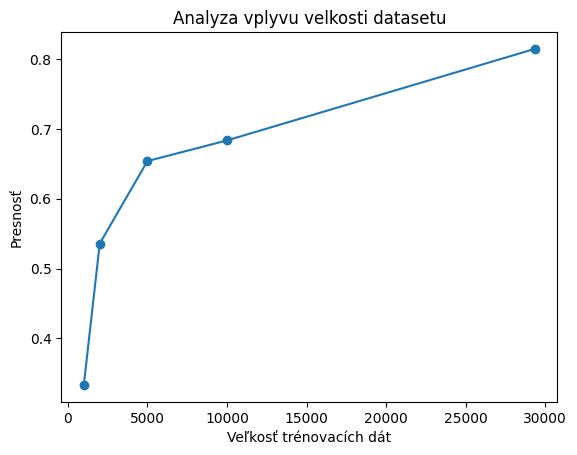

In [319]:
plt.plot(sizes, accuracies, marker="o")
plt.xlabel("Veľkosť trénovacích dát")
plt.ylabel("Presnosť")
plt.title("Analyza vplyvu velkosti datasetu")
plt.show()
